In [24]:
##### Calculate the transferability potential metric for each pixel in raster against capital and labor model training data

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import rasterio
from rasterio.transform import from_bounds
import xarray as xr
from glob import glob
from rasterio.warp import reproject, Resampling
import matplotlib.colors as mcolors
from pyproj import Transformer
import rioxarray as rio
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import TwoSlopeNorm

In [11]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import predictors data
capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final_thinned.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final_thinned.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Training_data/raster_predictor_matrix_relative.parquet")

# reference raster
ref_path = f"{cd}/Data/Clean/Production/total_production_tonnes_2020.tif"

# country boundaries 
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/transferability_metric"

In [12]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

#### Calculate dissimilarity index

In [3]:
#### Map columns across models and raster

# all columns (using model names) 
capital_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_sheep_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_cereals_share_base_100_production_tonnes',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_vegetables_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_share_base_100_large_field',
       'rtv_log_share_base_100_with_nightlights']

labor_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_rest_of_crops_share_base_100_production_tonnes',
       'rtv_log_sugar_crops_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_pct_base_100_GDP_ag', 'rtv_log_share_base_100_large_field',
       'rtv_log_pct_base_100_cropland_irrigated']

In [4]:
#### Prep data

# pull predictor data  
X_train_lab = labor_model[labor_cols].dropna()
X_pixel_raw_lab = raster_model[labor_cols] 

X_train_cap = capital_model[capital_cols].dropna()
X_pixel_raw_cap = raster_model[capital_cols] 

# mask to only include pixels with full data
valid_mask_lab = X_pixel_raw_lab.notna().all(axis=1)
valid_mask_cap = X_pixel_raw_cap.notna().all(axis=1)

# rescale predictors to 0 = mean SD = 1 (puts on comparable scale)
scaler = StandardScaler()

X_train_scaled_lab = scaler.fit_transform(X_train_lab)
X_pixel_scaled_lab = scaler.transform(X_pixel_raw_lab[valid_mask_lab])

X_train_scaled_cap = scaler.fit_transform(X_train_cap)
X_pixel_scaled_cap = scaler.transform(X_pixel_raw_cap[valid_mask_cap])

In [5]:
#### Calculate dissimilarity index for each pixel (Meyer & Pebesma, 2021)
# only neeed to re-run if underlying data has changed

# Calculate normalization factor from training data
# (the average 'distance' from each observation to the next closest observation)
nn_train_lab = NearestNeighbors(n_neighbors=2, n_jobs=-1) # set method to find nearest neighbor (2nd because 1st is itself)
nn_train_lab.fit(X_train_scaled_lab) # set reference data 
train_nn_dists_lab, _ = nn_train_lab.kneighbors(X_train_scaled_lab) # apply function to find nearest neighboor 
avg_train_nn_dist_lab = train_nn_dists_lab[:, 1].mean() # calculate average across training data, keeping only data for 2nd neighbor (not self)


nn_train_cap = NearestNeighbors(n_neighbors=2, n_jobs=-1) # set method to find nearest neighbor (2nd because 1st is itself)
nn_train_cap.fit(X_train_scaled_cap) # set reference data 
train_nn_dists_cap, _ = nn_train_cap.kneighbors(X_train_scaled_cap) # apply function to find nearest neighboor 
avg_train_nn_dist_cap = train_nn_dists_cap[:, 1].mean() # calculate average across training data, keeping only data for 2nd neighbor (not self)


# Calculate dissimilarity index for each pixel
nn_lab = NearestNeighbors(n_neighbors=1, n_jobs=-1) # set method to find nearest neighbor in training data (1st because self isn't in training data)
nn_lab.fit(X_train_scaled_lab) # set reference data 
pixel_nn_dists_lab, _ = nn_lab.kneighbors(X_pixel_scaled_lab) # apply function to find nearest neighboor for each pixel
pixel_nn_dists_lab = pixel_nn_dists_lab[:, 0] # convert to vector
DI_lab = pixel_nn_dists_lab / avg_train_nn_dist_lab # calculate DI by normalizing against avg_train_nn_dist

nn_cap = NearestNeighbors(n_neighbors=1, n_jobs=-1) # set method to find nearest neighbor in training data (1st because self isn't in training data)
nn_cap.fit(X_train_scaled_cap) # set reference data 
pixel_nn_dists_cap, _ = nn_cap.kneighbors(X_pixel_scaled_cap) # apply function to find nearest neighboor for each pixel
pixel_nn_dists_cap = pixel_nn_dists_cap[:, 0] # convert to vector
DI_cap = pixel_nn_dists_cap / avg_train_nn_dist_cap # calculate DI by normalizing against avg_train_nn_dist


# Calculate area of applicability threshold (Meyer & Pebesma, 2021)
# threshold is 95th percentile of DI distribution (from training points)
train_di_lab = train_nn_dists_lab[:, 1] / avg_train_nn_dist_lab  # calculate DI for training data
aoa_threshold_lab = np.percentile(train_di_lab, 95) # find the 95th percentile 

train_di_cap = train_nn_dists_cap[:, 1] / avg_train_nn_dist_cap  # calculate DI for training data
aoa_threshold_cap = np.percentile(train_di_cap, 95) # find the 95th percentile 

In [6]:
### Assemble output
# only neeed to re-run if underlying data has changed

# get x,y of pixel  
output_df = raster_model[['x', 'y']].copy()

# initialize columns 
output_df['DI_lab'] = np.nan
output_df['within_AOA_lab'] = np.nan

output_df['DI_cap'] = np.nan
output_df['within_AOA_cap'] = np.nan

# add in DI and binary measure of within AOA for each pixel 
output_df.loc[valid_mask_lab, 'DI_lab'] = DI_lab
output_df.loc[valid_mask_lab, 'within_AOA_lab'] = (DI_lab <= aoa_threshold_lab).astype(int)

output_df.loc[valid_mask_cap, 'DI_cap'] = DI_cap
output_df.loc[valid_mask_cap, 'within_AOA_cap'] = (DI_cap <= aoa_threshold_cap).astype(int)

output_df.to_csv(f"{fd}/DI_AOA_calcs.csv", index=False)

In [7]:
### Convert back to raster to plot (LABOR)

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI_lab'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI_lab'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA_lab'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_labor.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_labor.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

In [8]:
### Convert back to raster to plot (CAPITAL)

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI_cap'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI_cap'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA_cap'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_capital.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_capital.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

#### Plot dissimilarity index

In [22]:
##### Prep data

# load data
di_grid_labor = rio.open_rasterio(f'{fd}/DI_labor.tif')
di_grid_capital = rio.open_rasterio(f'{fd}/DI_capital.tif')
production = rio.open_rasterio(f"{cd}/Data/Clean/Production/total_production_USD_2020.tif")

# align crs
crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
di_grid_labor = di_grid_labor.rio.reproject(crs)
di_grid_capital = di_grid_capital.rio.reproject(crs)
production = production.rio.reproject(crs)  
country_boundaries = country_boundaries.to_crs(crs)

# filter to only pixels with produciton (only ones where model actually makes prediction)

production = production.rio.reproject_match(di_grid_capital)

# Mask nodata/fill values introduced by reprojection
di_grid_capital = di_grid_capital.where(di_grid_capital > 0)
di_grid_labor = di_grid_labor.where(di_grid_labor > 0)

di_plot_capital = di_grid_capital.squeeze()
di_grid_labor = di_grid_labor.squeeze()

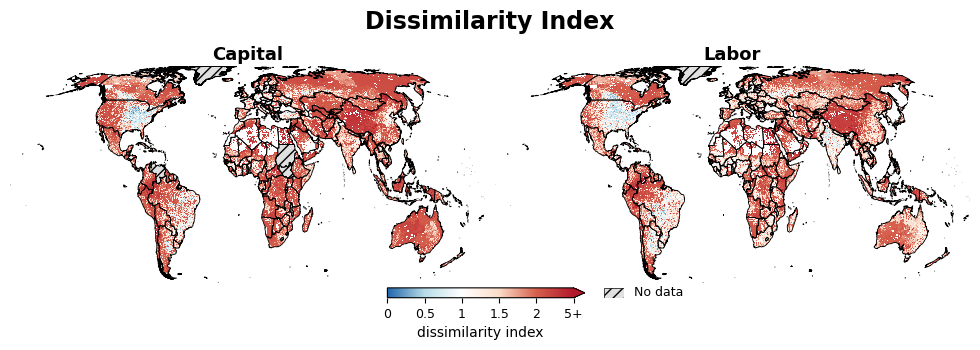

In [39]:
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import numpy as np

##### Global side-by-side map: capital (left) vs labor (right)

# set custom colormap — lighter blue and lighter red at the inner steps
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#2166ac", "#b8dce8", "#ffffff", "#fbdcc9", "#d6604d", "#b2182b"]
)
custom_cmap.set_over("#67001f")  # color for the 5+ triangle
custom_cmap.set_bad(color='none')

bounds = [0, 0.5, 1, 1.5, 2, 5]
labels = ['0', '0.5', '1', '1.5', '2', '5+']

positions = np.linspace(0, 1, len(bounds))

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

no_data_color = "#e0e0e0"

# --- Size figure to match the actual map aspect ratio ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)   # width / height of ONE map

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 2
fig_height = panel_height * 1.5  # small headroom for titles/colorbar, not 7.5

fig, axes = plt.subplots(
    1, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (di_grid_capital.squeeze(), "has_capital_data", "Capital", axes[0]),
    (di_grid_labor.squeeze(),   "has_labor_data",   "Labor",   axes[1]),
]

for value_plot, data_flag_col, title, ax in panels:

    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )
    im = value_plot.plot(
        ax=ax, cmap=custom_cmap, norm=norm,
        add_colorbar=False, add_labels=False, zorder=0
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Dissimilarity Index", fontsize=17, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.14, left=0.02, right=0.98)

# --- Shared colorbar ---
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    location="bottom",
    fraction=0.04,
    pad=0.02,
    shrink=0.35,
    extend='max',
    extendfrac=0.06,
)
cbar.set_label("dissimilarity index", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

fig.canvas.draw()

# --- No-data swatch ---
cbar_pos = cbar.ax.get_position()
swatch_size = 0.02
gap = 0.03

legend_ax = fig.add_axes([
    cbar_pos.x1 + gap, cbar_pos.y0, swatch_size, cbar_pos.height
])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1, facecolor=no_data_color, edgecolor="black",
    linewidth=0.5, hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis("off")

fig.text(
    cbar_pos.x1 + gap + swatch_size + 0.01,
    cbar_pos.y0 + cbar_pos.height / 2,
    "No data", fontsize=9, va="center", ha="left"
)

plt.show()
fig.savefig(f"{fd}/DI_raster_capital_labor.png", dpi=300, bbox_inches='tight')